
🔹 Processing Subset 1
Silhouette Score: 0.0669
Adjusted Rand Index: 0.0000
Dunn Index: 0.0452


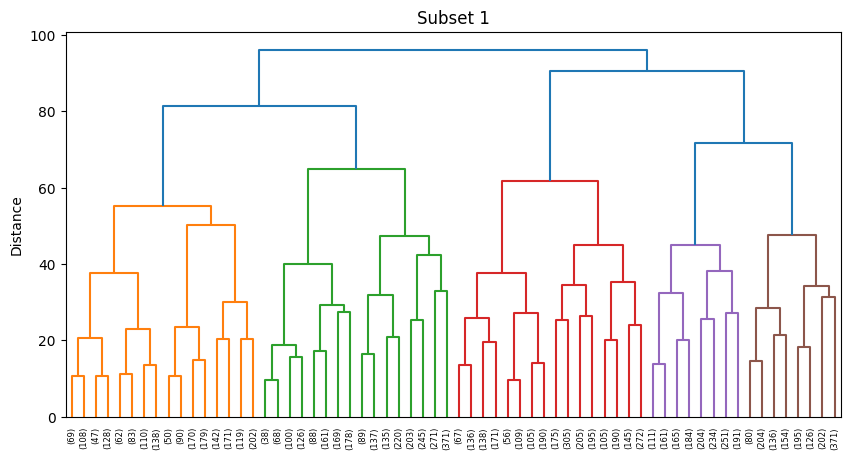


🔹 Processing Subset 2
Silhouette Score: 0.1443
Adjusted Rand Index: -0.0001
Dunn Index: 0.0972


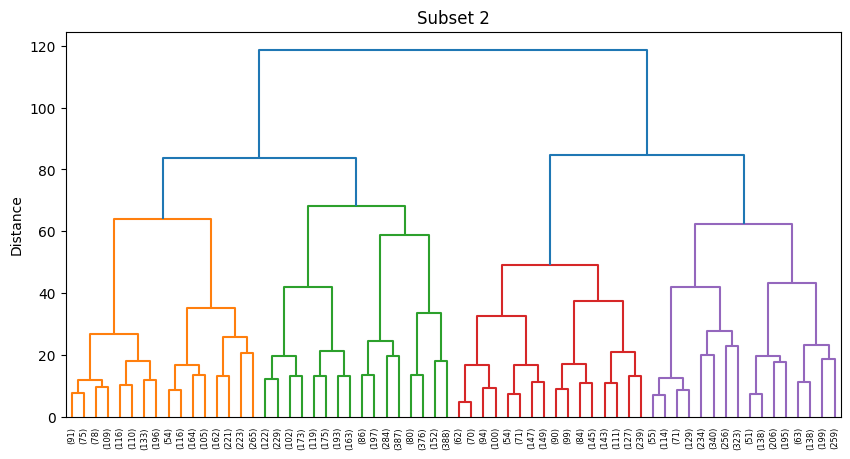


🔹 Processing Subset 3
Silhouette Score: 0.1615
Adjusted Rand Index: 0.0001
Dunn Index: 0.0880


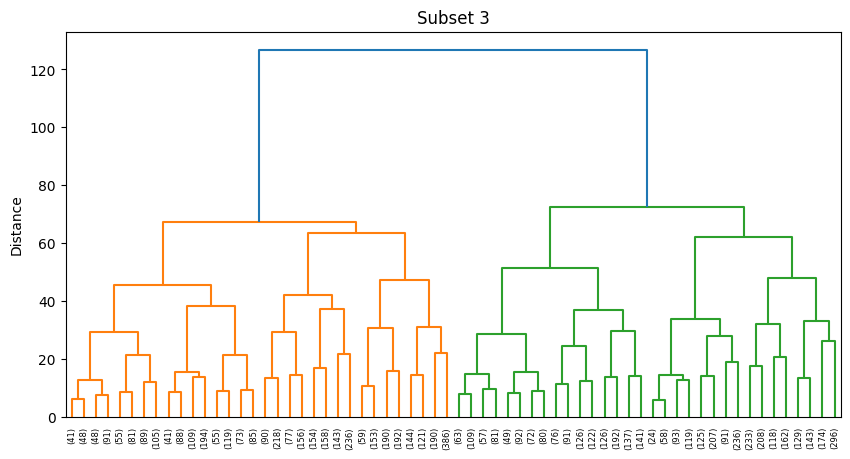


🔹 Processing Subset 4
Silhouette Score: 0.1479
Adjusted Rand Index: 0.0000
Dunn Index: 0.0379


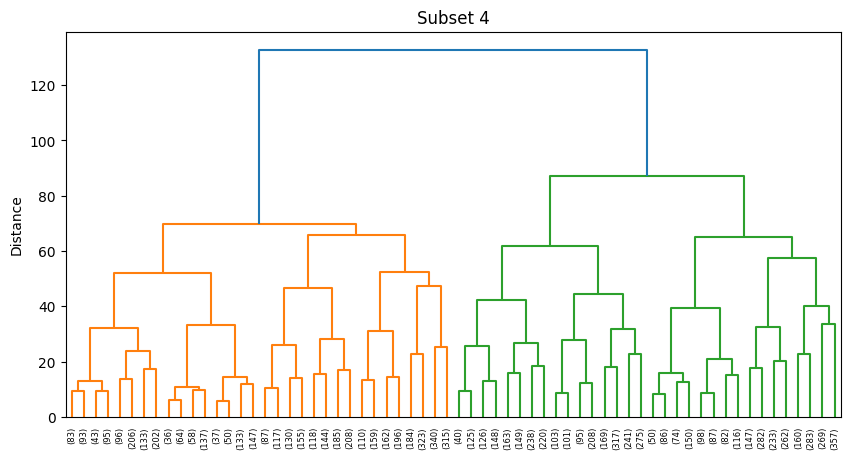


🔹 Processing Subset 5
Silhouette Score: 0.1204
Adjusted Rand Index: 0.0000
Dunn Index: 0.0249


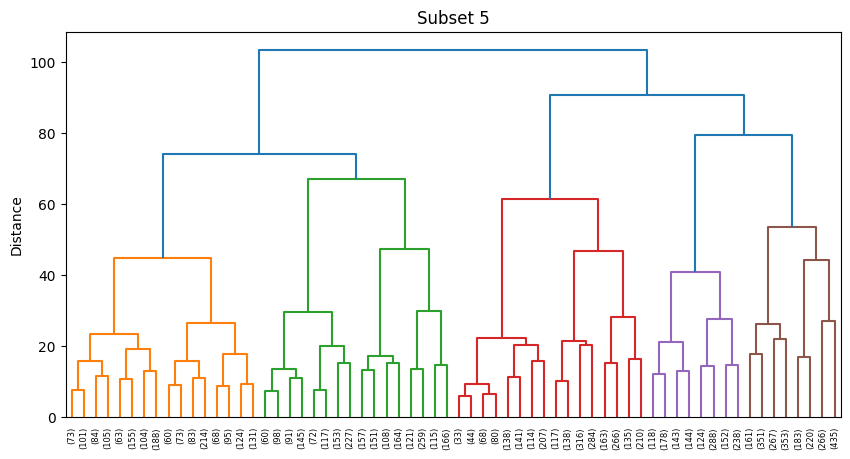


🔹 Processing Subset 6
Silhouette Score: 0.1020
Adjusted Rand Index: 0.0000
Dunn Index: 0.0375


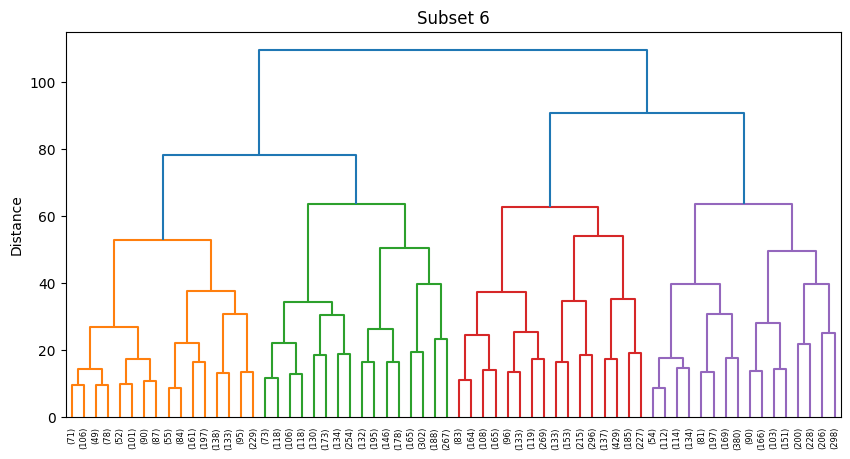


🔹 Processing Subset 7
Silhouette Score: 0.1212
Adjusted Rand Index: -0.0001
Dunn Index: 0.0291


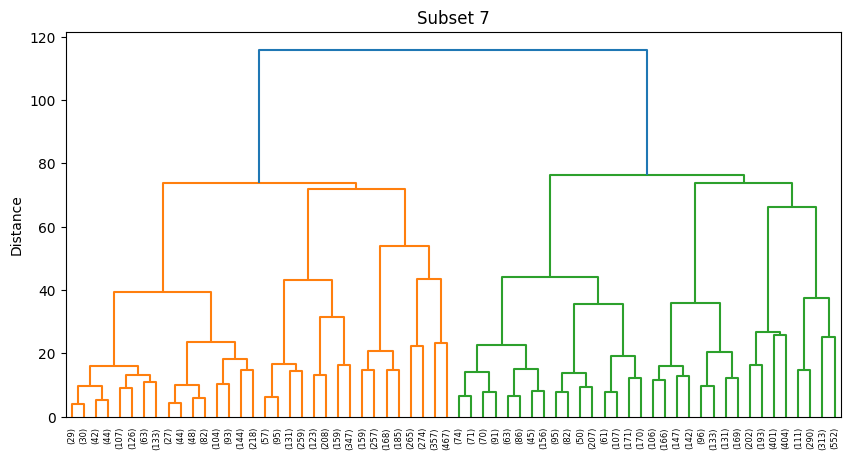


🔹 Processing Subset 8
Silhouette Score: 0.2290
Adjusted Rand Index: 0.0000
Dunn Index: 0.1639


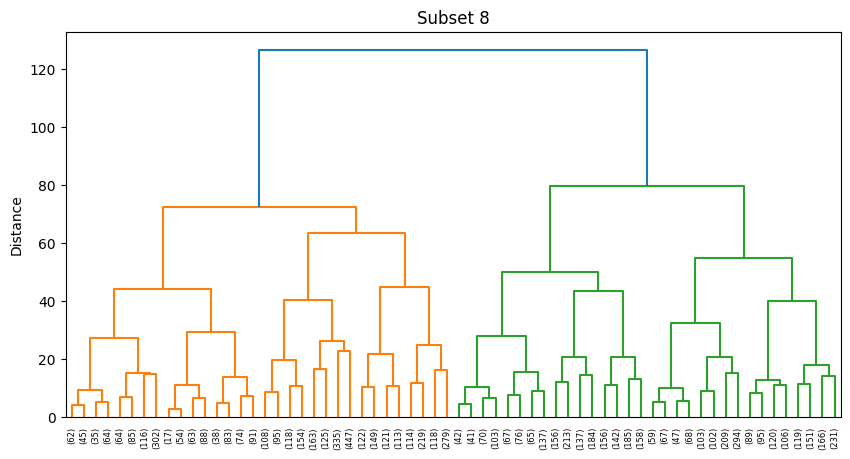


🔹 Processing Subset 9
Silhouette Score: 0.1625
Adjusted Rand Index: 0.0000
Dunn Index: 0.0222


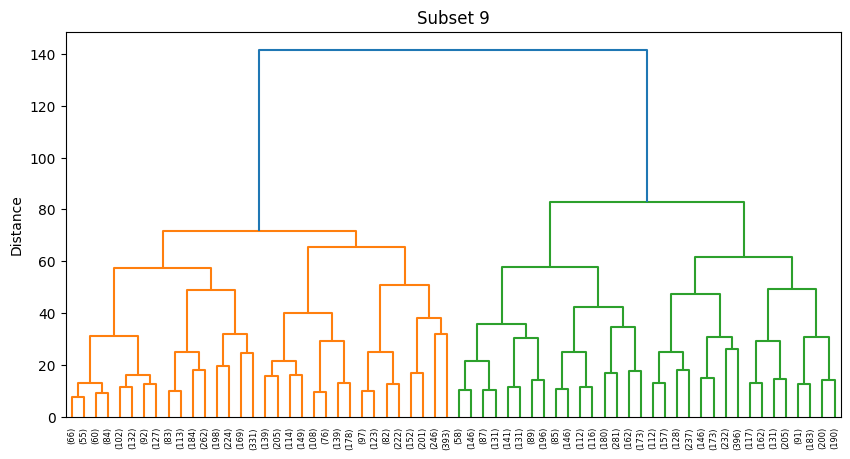


🔹 Processing Subset 10
Silhouette Score: 0.1254
Adjusted Rand Index: 0.0000
Dunn Index: 0.0244


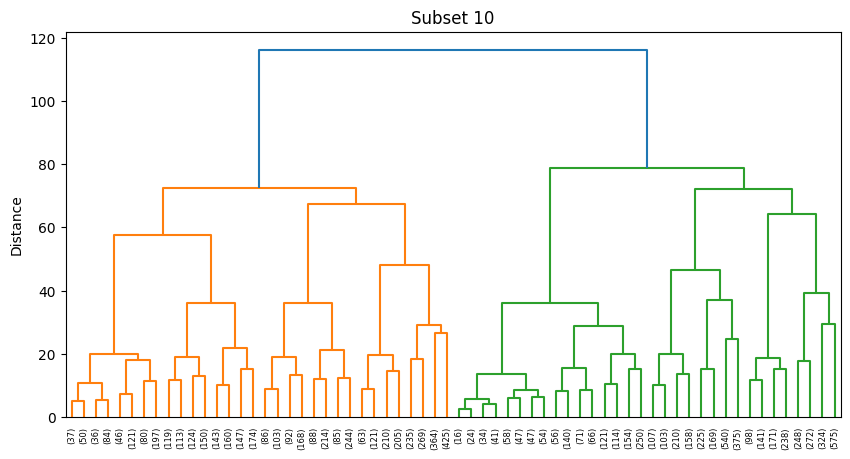


🔹 Processing Subset 11
Silhouette Score: 0.3612
Adjusted Rand Index: 0.0004
Dunn Index: 0.1564


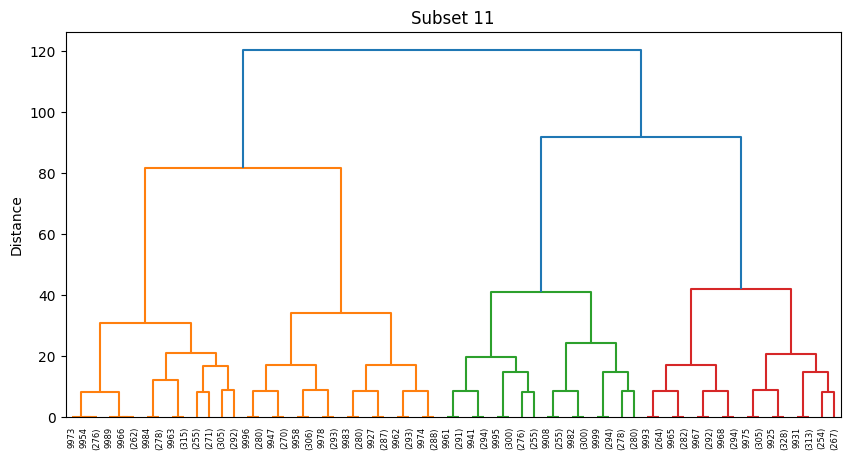


🔹 Processing Subset 12
Silhouette Score: 0.4188
Adjusted Rand Index: 0.0000
Dunn Index: 0.2573


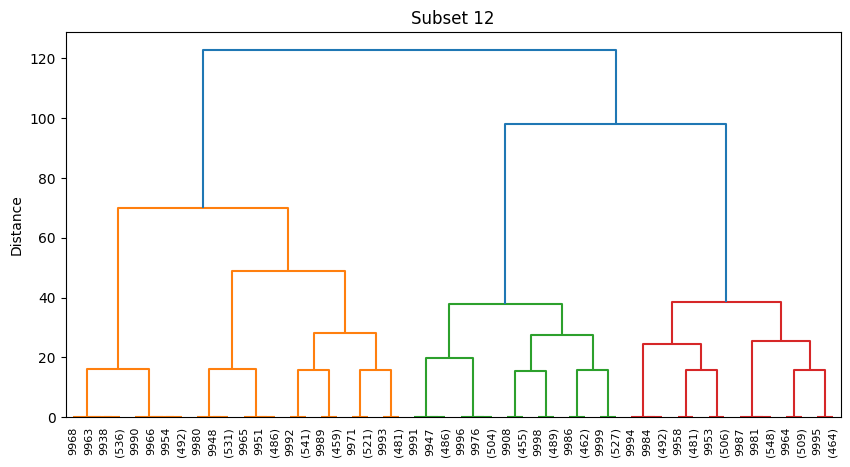


🔹 Processing Subset 13
Silhouette Score: 0.2125
Adjusted Rand Index: -0.0000
Dunn Index: 0.0120


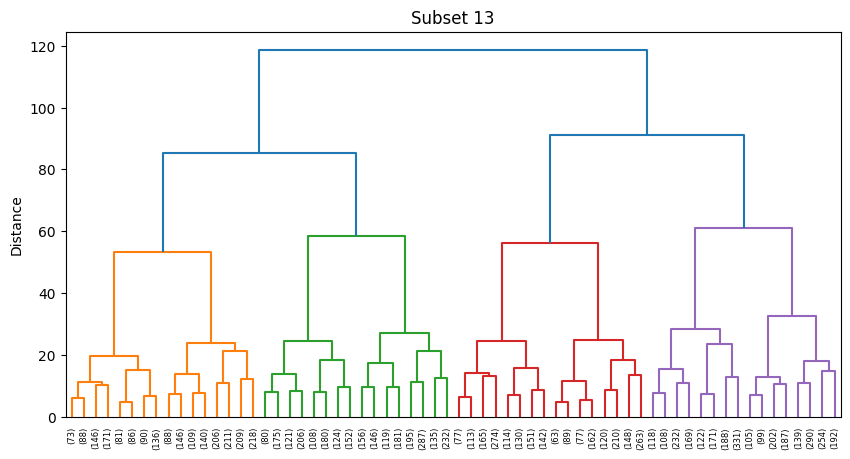


🔹 Processing Subset 14
Silhouette Score: 0.4177
Adjusted Rand Index: -0.0001
Dunn Index: 0.2572


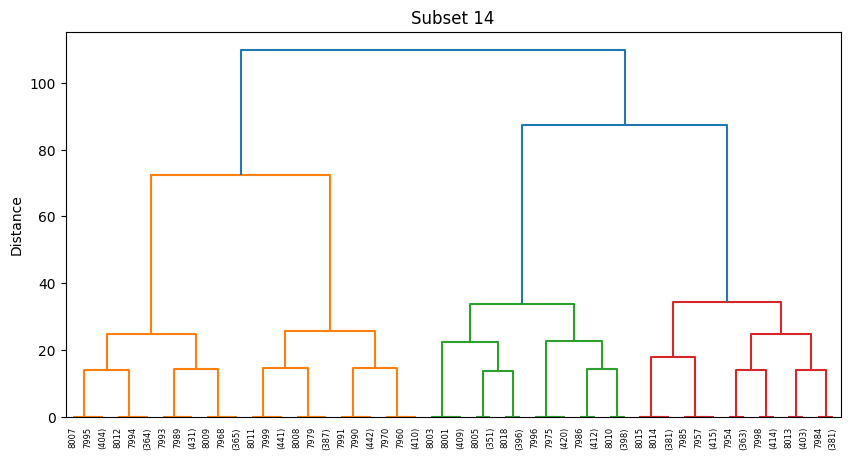


🔹 Processing Subset 15
Silhouette Score: 0.3148
Adjusted Rand Index: 0.0000
Dunn Index: 0.0005


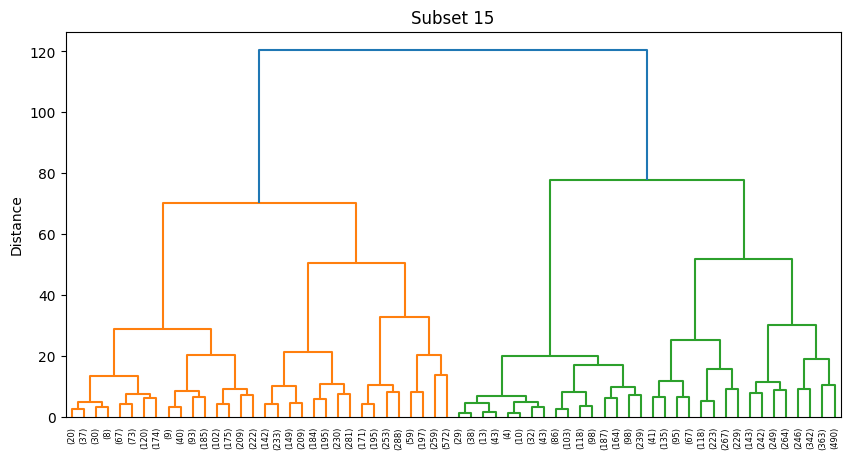


🔹 Processing Subset 16
Silhouette Score: 0.2088
Adjusted Rand Index: -0.0001
Dunn Index: 0.1135


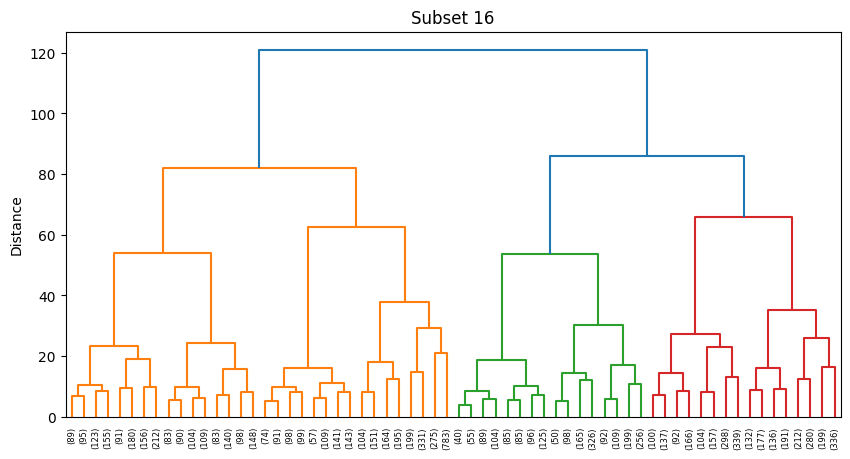


🔹 Processing Subset 17
Silhouette Score: 0.2088
Adjusted Rand Index: -0.0001
Dunn Index: 0.1135


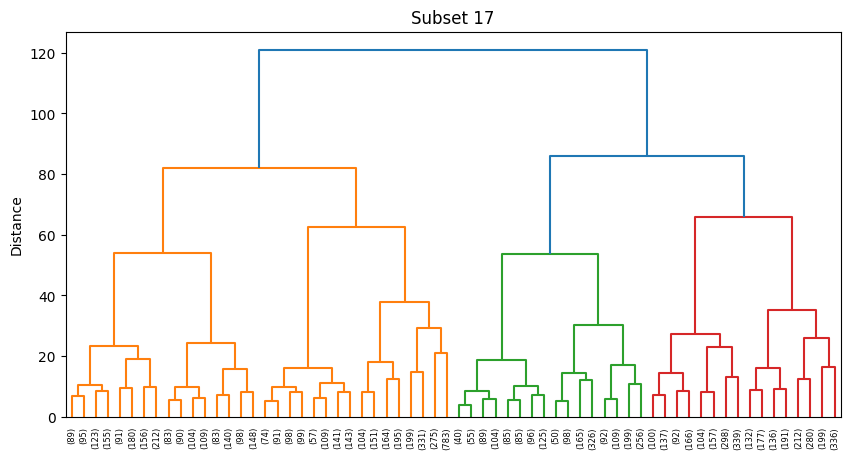


🔹 Processing Subset 18
Silhouette Score: 0.1805
Adjusted Rand Index: 0.0000
Dunn Index: 0.0035


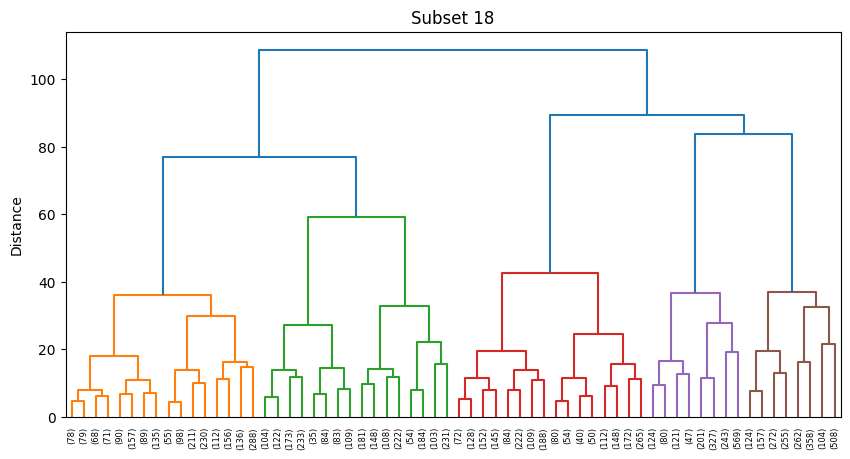


🔹 Processing Subset 19
Silhouette Score: 0.3142
Adjusted Rand Index: 0.0000
Dunn Index: 0.1433


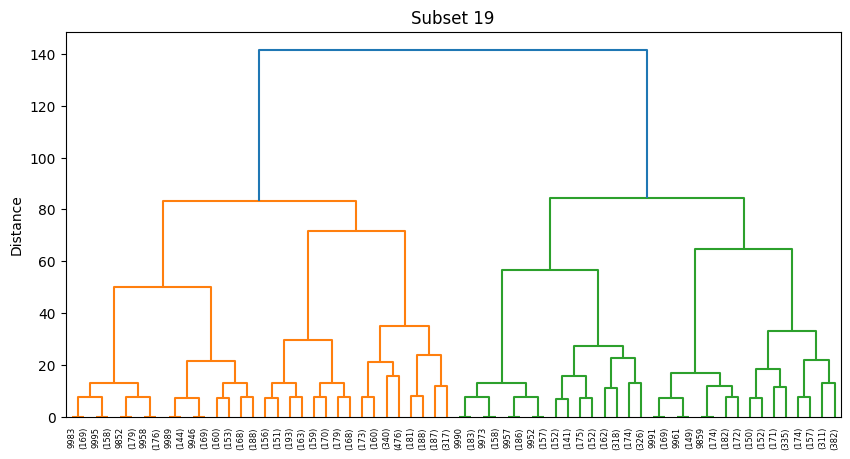


🔹 Processing Subset 20
Silhouette Score: 0.1531
Adjusted Rand Index: 0.0001
Dunn Index: 0.0107


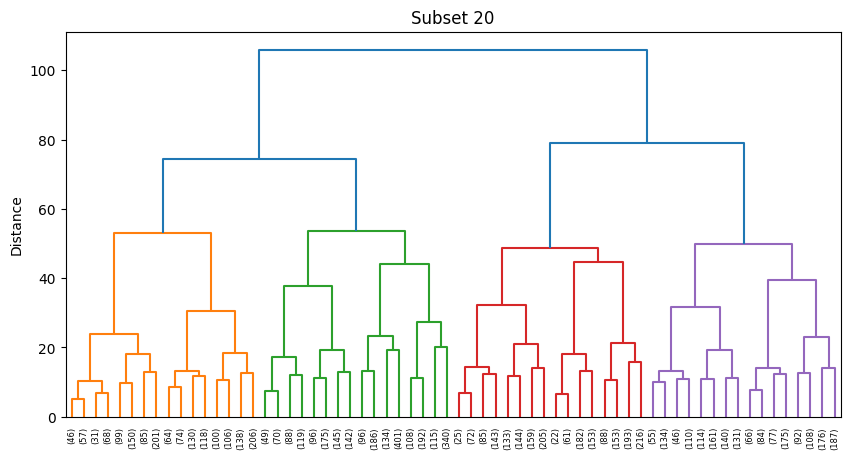


📊 FINAL PERFORMANCE MATRIX:
    Subset  Silhouette           ARI      Dunn
0        1    0.066858  0.000000e+00  0.045248
1        2    0.144320 -1.258719e-04  0.097237
2        3    0.161503  1.202322e-04  0.087971
3        4    0.147930  5.149408e-07  0.037897
4        5    0.120435  0.000000e+00  0.024894
5        6    0.102019  0.000000e+00  0.037465
6        7    0.121197 -1.266950e-04  0.029106
7        8    0.229039  0.000000e+00  0.163945
8        9    0.162482  0.000000e+00  0.022224
9       10    0.125417  0.000000e+00  0.024402
10      11    0.361160  3.759427e-04  0.156361
11      12    0.418845  3.006887e-05  0.257252
12      13    0.212465 -1.057537e-06  0.011953
13      14    0.417714 -1.336903e-04  0.257171
14      15    0.314840  4.416219e-05  0.000475
15      16    0.208838 -6.154453e-05  0.113497
16      17    0.208838 -6.154453e-05  0.113497
17      18    0.180495  4.744761e-05  0.003544
18      19    0.314238  4.864900e-05  0.143299
19      20    0.153126  1.02840

In [1]:
# -----------------------------
# IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform
import ast

# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_csv("Bird_Migration_Data_csv.csv")

# -----------------------------
# QUESTIONS DICTIONARY
# -----------------------------
questions_dict = {
    1: {"target":"End_Longitude", "support":["Species","Region","Habitat","Weather_Condition","End_Latitude","Migration_Reason"]},
    2: {"target":"Migration_Success", "support":["Migration_Reason","Species","Weather_Condition","Habitat"]},
    3: {"target":"Migration_Success", "support":["Interrupted_Reason","Weather_Condition","Habitat","Species","Migration_Interrupted"]},
    4: {"target":"Flight_Distance_km", "support":["Start_Latitude","Start_Longitude","End_Latitude","End_Longitude","Migration_Success"]},
    5: {"target":"End_Longitude", "support":["Species","Start_Latitude","Start_Longitude","End_Latitude"]},
    6: {"target":"End_Longitude", "support":["Species","Start_Latitude","Start_Longitude","End_Latitude","Region"]},
    7: {"target":"Migration_Success", "support":["Start_Latitude","Start_Longitude","End_Latitude","End_Longitude"]},
    8: {"target":"Origin", "support":["End_Latitude","End_Longitude","Interrupted_Reason","Migration_Success"]},
    9: {"target":"Origin", "support":["Migration_Success","Region","Habitat","Start_Latitude","End_Latitude"]},
    10: {"target":"Origin", "support":["Observation_Counts","Species","End_Latitude","End_Longitude"]},
    11: {"target":"Migration_Success", "support":["Species","Weather_Condition"]},
    12: {"target":"Observation_Counts", "support":["Weather_Condition","Migration_Reason"]},
    13: {"target":"Flight_Distance_km", "support":["Species","Start_Latitude","Start_Longitude"]},
    14: {"target":"Migration_Success", "support":["Interrupted_Reason","Weather_Condition"]},
    15: {"target":"Observation_Counts", "support":["Flight_Distance_km","Species"]},
    16: {"target":"Migration_Success", "support":["Species","Habitat","Weather_Condition"]},
    17: {"target":"Migration_Success", "support":["Weather_Condition","Habitat","Species"]},
    18: {"target":"Migration_Success", "support":["Flight_Distance_km","Species","Habitat"]},
    19: {"target":"Migration_Success", "support":["Weather_Condition","Habitat","Migration_Interrupted"]},
    20: {"target":"Migration_Success", "support":["Species","Interrupted_Reason","Weather_Condition","Flight_Distance_km"]}
}

# -----------------------------
# DATA CLEANING FUNCTION
# -----------------------------
def clean_universal_data(data_frame):
    temp_df = data_frame.copy()
    
    for col in temp_df.columns:
        temp_df[col] = temp_df[col].fillna('Unknown')
        
        first_val = str(temp_df[col].iloc[0]).strip()
        if first_val.startswith('(') and first_val.endswith(')'):
            try:
                coords = temp_df[col].apply(lambda x: ast.literal_eval(str(x)))
                temp_df[f'{col}_lat'] = coords.apply(lambda x: float(x[0]))
                temp_df[f'{col}_long'] = coords.apply(lambda x: float(x[1]))
                temp_df.drop(columns=[col], inplace=True)
                continue
            except:
                pass

        if not pd.api.types.is_numeric_dtype(temp_df[col]):
            temp_df[col] = LabelEncoder().fit_transform(temp_df[col].astype(str))
            
    return temp_df

# -----------------------------
# DUNN INDEX FUNCTION
# -----------------------------
def dunn_index(X, labels):
    distances = squareform(pdist(X))
    unique_clusters = np.unique(labels)
    
    intra_dist = []
    inter_dist = []

    for i in unique_clusters:
        cluster_i = np.where(labels == i)[0]
        if len(cluster_i) > 1:
            intra_dist.append(np.max(distances[np.ix_(cluster_i, cluster_i)]))

        for j in unique_clusters:
            if i < j:
                cluster_j = np.where(labels == j)[0]
                inter_dist.append(np.min(distances[np.ix_(cluster_i, cluster_j)]))

    if len(intra_dist) == 0:
        return 0

    return np.min(inter_dist) / np.max(intra_dist)

# -----------------------------
# MAIN LOOP
# -----------------------------
results = []

for q_id, info in questions_dict.items():
    print(f"\n🔹 Processing Subset {q_id}")

    support_cols = info['support']
    target_col = info['target']

    subset = df[support_cols + [target_col]].dropna()

    X_raw = subset[support_cols]
    y_raw = subset[target_col]

    # Clean
    X = clean_universal_data(X_raw)
    y = LabelEncoder().fit_transform(y_raw.astype(str))

    # Scale
    X_scaled = StandardScaler().fit_transform(X)

    # Hierarchical clustering
    Z = linkage(X_scaled, method='ward')

    # Form clusters (assume 3 clusters, can adjust)
    labels = fcluster(Z, t=3, criterion='maxclust')

    # -----------------------------
    # PERFORMANCE METRICS
    # -----------------------------
    sil_score = silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(y, labels)
    dunn = dunn_index(X_scaled, labels)

    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Adjusted Rand Index: {ari:.4f}")
    print(f"Dunn Index: {dunn:.4f}")

    results.append([q_id, sil_score, ari, dunn])

    # -----------------------------
    # DENDROGRAM
    # -----------------------------
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='level', p=5)
    plt.title(f"Subset {q_id}")
    plt.ylabel("Distance")
    plt.show()

# -----------------------------
# FINAL RESULTS TABLE
# -----------------------------
results_df = pd.DataFrame(results, columns=["Subset", "Silhouette", "ARI", "Dunn"])
print("\n📊 FINAL PERFORMANCE MATRIX:")
print(results_df)